# Example: Unicycle Robot solved by [Uniform grid abstraction](https://github.com/dionysos-dev/Dionysos.jl/blob/master/docs/src/manual/manual.md#solvers).

This example was adapted from the numerical experiments in [1, Sec. 5] from Symbolically guided Model Predictive Control (SgMPC)  [paper](https://doi.org/10.1016/j.ifacol.2022.09.039)..
This is a **control problem** for a **discrete-time nonlinear system**.

Let us consider the 3-dimensional state space control system of the form
$$
x_{t+1} = f(x_t, u_t)
$$
with $f: \mathbb{R}^3 × \mathbb{R}^2 \to \mathbb{R}^3$ given by
$$
f(x, (u_1, u_2)) = \begin{bmatrix} x_1 + u_1 \cos(x_3) \\ x_2 + u_1 \sin(x_3) \\ x_3 + u_2 \ (\text{mod} \ 2\pi) \end{bmatrix}
$$
and with state and control constraints given by:
$$
X = \left\{ (x_1, x_2)^T \in \mathbb{R}^2 \ | \ x_1^2 - x_2^2 \leq 4, \ 4x_2^2 - x_1^2 \leq 16 \right\}
$$
$$
U = [0.2, 2] \times [-1, 1]
$$
Here, $(x_1, x_2)$ represents the 2D Cartesian coordinates and $x_3$ is the angular orientation of a mobile cart.
The control inputs $u_1$ and $u_2$ are the linear and angular velocities.
The control objective is to drive the mobile cart to a desired reference position $x_r$.

Considering this as a reachability problem, we will use it to showcase the capabilities of the Uniform grid abstraction solving discrete-time problem in Dionysos.
The nonlinear constraints are handled as obstacles in the state-space.

First, let us import [StaticArrays](https://github.com/JuliaArrays/StaticArrays.jl) and [Plots](https://github.com/JuliaPlots/Plots.jl).

In [1]:
using StaticArrays, JuMP, Plots

using Symbolics
using MathOptSymbolicAD

At this point, we import Dionysos and JuMP.

In [2]:
using Dionysos
const DI = Dionysos
const UT = DI.Utils
const ST = DI.System
const MP = DI.Mapping
const SY = DI.Symbolic

Dionysos.Symbolic

Define the problem using JuMP
We first create a JuMP model:

In [3]:
model = Model(Dionysos.Optimizer);

Define the discretization step

In [4]:
hx = 0.1;

Define the state variables: x1(t), x2(t), x3(t) without specifying the start value since here it's a set. We will specify the start later using constraints.

In [5]:
x_low = [-3.5, -2.6, -pi]
x_upp = -x_low
@variable(model, x_low[i] <= x[i = 1:3] <= x_upp[i]);

Define the control variables: u1(t), u2(t)

In [6]:
@variable(model, -1 <= u[1:2] <= 1);

Define the dynamics, we do not include the remainder modulo `2π` for `Δ(x[3])`. There are options to set periodic variables in Dionysos but that's not needed for this example.

In [7]:
@constraint(model, Δ(x[1]) == x[1] + u[1] * cos(x[3]))
@constraint(model, Δ(x[2]) == x[2] + u[1] * sin(x[3]))
@constraint(model, Δ(x[3]) == x[3] + u[2])

Δ(x[3]) - (x[3] + u[2]) = 0

Define the initial and target sets

In [8]:
x_initial = [1.0, -1.7, 0.0]
x_target = [sqrt(32) / 3, sqrt(20) / 3, -pi]

@constraint(model, start(x[1]) in MOI.Interval(x_initial[1] - hx, x_initial[1] + hx))
@constraint(model, start(x[2]) in MOI.Interval(x_initial[2] - hx, x_initial[2] + hx))
@constraint(model, start(x[3]) in MOI.Interval(x_initial[3] - hx, x_initial[3] + hx))

@constraint(model, final(x[1]) in MOI.Interval(x_target[1] - hx, x_target[1] + hx))
@constraint(model, final(x[2]) in MOI.Interval(x_target[2] - hx, x_target[2] + hx))
@constraint(model, final(x[3]) in MOI.Interval{Float64}(-pi, pi))

final(x[3]) ∈ [-3.141592653589793, 3.141592653589793]

Obstacle boundaries computed using the function `get_obstacles` below

In [9]:
function extract_rectangles(matrix)
    if isempty(matrix)
        return []
    end

    n, m = size(matrix)
    tlx, tly, brx, bry = Int[], Int[], Int[], Int[]

    # Build histogram heights
    for i in 1:n
        j = 1
        while j <= m
            if matrix[i, j] == 1
                j += 1
                continue
            end
            push!(tlx, j)
            push!(tly, i)
            while j <= m && matrix[i, j] == 0
                j += 1
            end
            push!(brx, j - 1)
            push!(bry, i)
        end
    end

    return zip(tlx, tly, brx, bry)
end

function get_obstacles(lb, ub, h)
    # lb_x1 = -3.5, ub_x1 = 3.5, lb_x2 = -2.6, ub_x2 = 2.6, h = 0.1
    lb_x1, lb_x2, lb_x3 = lb
    ub_x1, ub_x2, ub_x3 = ub

    # Define the obstacles
    x1 = range(lb_x1; stop = ub_x1, step = h)
    x2 = range(lb_x2; stop = ub_x2, step = h)
    steps1, steps2 = length(x1), length(x2)

    X1 = x1' .* ones(steps2)
    X2 = ones(steps1)' .* x2

    Z1 = (X1 .^ 2 .- X2 .^ 2) .<= 4
    Z2 = (4 .* X2 .^ 2 .- X1 .^ 2) .<= 16

    # Find the upper and lower bounds of X1 and X2 for the obstacle
    grid = Z1 .& Z2

    return [
        MOI.HyperRectangle([x1[x1lb], x2[x2lb]], [x1[x1ub], x2[x2ub]]) for
        (x1lb, x2lb, x1ub, x2ub) in extract_rectangles(grid)
    ]
end

obstacles = get_obstacles(x_low, x_upp, hx);

Function to add rectangular obstacle avoidance constraints

In [10]:
for obstacle in obstacles
    @constraint(model, x[1:2] ∉ obstacle)
end

### Definition of the abstraction

We define the growth bound function of $f$ (`|u₁|`: a growth bound is a
radius and must be nonnegative for every admissible input):

In [11]:
function growth_bound(r, u)
    β = abs(u[1]) * r[3]
    return StaticArrays.SVector{3}(β, β, 0.0)
end
set_attribute(model, "growthbound_map", growth_bound)

Definition of the grid of the state-space on which the abstraction is based (origin `x0` and state-space discretization `h`):

In [12]:
x0 = SVector(0.0, 0.0, 0.0);
h = SVector(hx, hx, 0.2);
set_attribute(model, "state_grid", MP.GridFree(x0, h))

Definition of the grid of the input-space on which the abstraction is based (origin `u0` and input-space discretization `h`):

In [13]:
u0 = SVector(1.1, 0.0);
h = SVector(0.3, 0.3);
set_attribute(model, "input_grid", MP.GridFree(u0, h))

optimize!(model);

>>Setting up the model
>>Model setup complete
[ Info: Number of states: 64263
[ Info: Number of inputs: 49
[ Info: Number of forward images: 3148887
┌ Warning: Noise is not yet accounted for in system abstraction.
└ @ Dionysos.Optim.Abstraction.UniformGridAbstraction ~/.julia/packages/Dionysos/haa33/src/optim/continuous_systems/UniformGridAbstraction/alternating_simulation_problem.jl:642
compute_abstract_system_from_concrete_system!: started
[ Info: Starting sequential abstraction
┌ Info: Sequential abstraction progress
│   done = 100000
└   total = 3148887
┌ Info: Sequential abstraction progress
│   done = 200000
└   total = 3148887
┌ Info: Sequential abstraction progress
│   done = 300000
└   total = 3148887
┌ Info: Sequential abstraction progress
│   done = 400000
└   total = 3148887
┌ Info: Sequential abstraction progress
│   done = 500000
└   total = 3148887
┌ Info: Sequential abstraction progress
│   done = 600000
└   total = 3148887
┌ Info: Sequential abstraction progress
│   do

Get the results

In [14]:
abstract_system = get_attribute(model, "abstract_system");
abstract_problem = get_attribute(model, "abstract_problem");
abstract_controller = get_attribute(model, "abstract_controller");
abstract_value_function = get_attribute(model, "abstract_value_function");
concrete_controller = get_attribute(model, "concrete_controller");
concrete_problem = get_attribute(model, "concrete_problem");
concrete_system = concrete_problem.system;

### Trajectory display
We choose a stopping criterion `reached` and the maximal number of steps `nsteps` for the sampled system, i.e. the total elapsed time: `nstep`*`Δt`
as well as the true initial state `x0` which is contained in the initial state-space `_I_` defined previously.

In [15]:
nstep = 100
reached(x) = x ∈ concrete_problem.target_set

x_traj, u_traj = ST.get_closed_loop_trajectory(
    get_attribute(model, "discrete_time_system"),
    concrete_controller,
    x_initial,
    nstep;
    stopping = reached,
)

using Plots

Here we display the coordinate projection on the two first components of the state space along the trajectory.

In [16]:
fig = plot(; aspect_ratio = :equal);

We display the concrete domain (the set-minus recipe projects on `dims = [1, 2]`)

In [17]:
plot!(concrete_system.X; color = :grey, opacity = 0.5, label = "");

We display the abstract domain

In [18]:
plot!(abstract_system; value_function = abstract_value_function);

We display the concrete specifications (projected on the plotted coordinates)

In [19]:
plot!(
    UT.project_set(concrete_problem.initial_set, [1, 2]);
    color = :green,
    opacity = 0.5,
    label = "Initial set",
);
plot!(
    UT.project_set(concrete_problem.target_set, [1, 2]);
    color = :red,
    opacity = 0.5,
    label = "Target set",
);

We display the abstract specifications

In [20]:
Xmapping = SY.get_state_mapping(abstract_system)
plot!(
    (SY.get_state_set_from_states(abstract_system, abstract_problem.initial_set), Xmapping);
    color = :green,
);
plot!(
    (SY.get_state_set_from_states(abstract_system, abstract_problem.target_set), Xmapping);
    color = :red,
    efficient = false,
);

We display the concrete trajectory

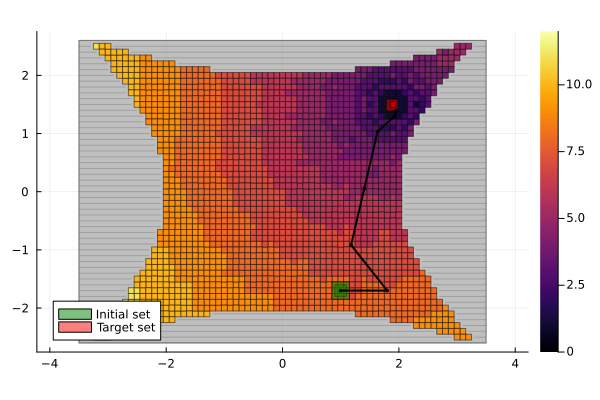

In [21]:
plot!(x_traj; ms = 2.0, arrows = false, lw = 2)

### References
1. Z. Azaki, A. Girard and S. Olaru, "Predictive and Symbolic Control: Performance and Safety for Non-linear Systems," in IFAC-PapersOnLine, 2022, vol. 55, no 16, pp. 290-295..

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*